# Armillary tutorial

Armillary builds a coordinate system for a set of stellar spectra from the spectra alone, and then carries labels (effective temperature, surface gravity, metallicity, or anything else measured for a few stars) to every other star through that coordinate system. This notebook runs the method on synthetic spectra whose labels are known exactly, so that every step can be checked against the truth: first the showcase of the paper (Ting & Saad 2026), a grid of spectra whose label box is recovered by the coordinates with no label ever used; then the seven steps of the method drawn one by one on real spectra; then the transfer of labels from a few stars to a survey-like sample, with and without noise; and finally how the same calls apply to your own survey.

The five steps of the method, and the module that implements each:

| step | what it does | module |
| --- | --- | --- |
| 1 | normalise each spectrum to a local continuum and measure a distance between every pair of spectra, from the cumulative absorption in a hierarchy of wavelength chunks | `preprocess`, `distance` |
| 2 | join every star to its nearest neighbours under that distance into one connected graph, and measure geodesic distances along it | `lattice` |
| 3 | turn the geodesic distances into coordinates (landmark multidimensional scaling) | `coordinates` |
| 4 | refine the coordinates so that every star is a local linear combination of its neighbours | `refine` |
| 5 | transfer labels from a few labelled stars to all the others through the same local combinations | `labels` |

`armillary.fit` runs steps 1 to 4 and returns a `Fit`; `Fit.propagate` is step 5.

In [1]:
import sys, numpy as np, matplotlib.pyplot as plt
import armillary as ar
from armillary import evaluate as ev
sys.path.insert(0, "examples"); import tutorial_figures as tf      # the figures, in the paper's style
print("armillary", ar.__version__)

armillary 0.2.0


## 1. The example spectra

`examples/synthetic_spectra.npz` holds 6,775 synthetic spectra from 480 to 680 nm at a resolving power of 10,000, calculated with [Payne Zero](https://github.com/tingyuansen/payne-zero) and continuum-normalised, in three samples:

- **grid** (4,675): every combination of effective temperature from 4000 to 7000 K in steps of 125 K, surface gravity from 1 to 5 in steps of 0.25, and metallicity from −2 to +0.5 in steps of 0.25;
- **population** (1,500): a survey-like mix of main-sequence stars, subgiants, red giants and red-clump stars;
- **random** (600): uniform draws over the same label box.

Each spectrum comes with its true effective temperature, surface gravity and metallicity.

Synthetic stellar spectra for the Armillary tutorial: Payne Zero one-dimensional LTE synthesis, 480 to 680 nm, degraded to a resolving power of 10,000 and sampled at 2.5 pixels per resolution element, continuum-normalised. 'grid' (4,675): Teff 4000-7000 K in steps of 125 K x log g 1-5 in steps of 0.25 x [Fe/H] -2 to +0.5 in steps of 0.25; 'population' (1,500): a survey-like mix of main-sequence stars, subgiants, red giants and red-clump stars; 'random' (600): uniform draws over the same box. All have [alpha/M] = 0 and 1.5 km/s microturbulence. Arrays: flux [N, P] float16 (precision 5e-4; cast to float32 to use), wavelength_nm [P] float64, labels [N, 3] float32 (Teff, log g, [Fe/H]), sample [N] str.
(6775, 8702) spectra x pixels: {'grid': 4675, 'population': 1500, 'random': 600}


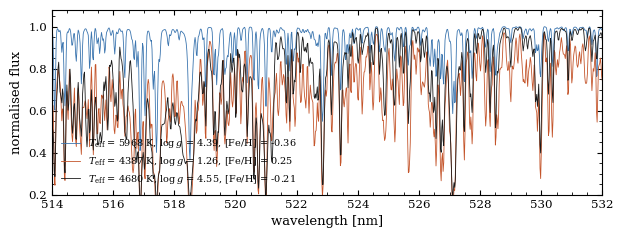

In [2]:
z = np.load("examples/synthetic_spectra.npz")
flux = z["flux"].astype(np.float32); wl = z["wavelength_nm"]; labels = z["labels"].astype(float); sample = z["sample"]
print(str(z["readme"]))
print(flux.shape, "spectra x pixels:", {s: int((sample == s).sum()) for s in ("grid", "population", "random")})

fig, ax = plt.subplots(figsize=(tf.fs.FULL_WIDTH, 2.4))
for i, c in zip(np.where(sample == "population")[0][[0, 300, 900]], [tf.fs.BLUE, tf.fs.ORANGE, tf.fs.INK]):
    ax.plot(wl, flux[i], lw=0.6, color=c, label=rf"$T_{{\rm eff}}$ = {labels[i,0]:.0f} K, $\log g$ = {labels[i,1]:.2f}, [Fe/H] = {labels[i,2]:.2f}")
ax.set_xlim(514, 532); ax.set_ylim(0.2, 1.08); ax.set_xlabel("wavelength [nm]"); ax.set_ylabel("normalised flux"); ax.legend(fontsize=7, loc="lower left"); plt.show()

## 2. The showcase: a label grid recovered from the spectra alone

Run the method on the 4,675 grid spectra. `fit` needs the flux, a boolean mask of the usable pixels, and the detector segment of every pixel (one segment here). `Config.paper_synthetic()` is the setting of the paper's synthetic experiments: one chunking of 32 wavelength chunks, three coordinates, and the refinement over each star's 50 nearest neighbours. The exact neighbour search is fine at this size; `search="nndescent"` is the setting for a survey of hundreds of thousands. The run takes about a minute.

In [3]:
grid = sample == "grid"
Fg = ar.fit(flux[grid], np.ones(flux[grid].shape, bool), np.zeros(flux.shape[1], int), ar.Config.paper_synthetic())
print("eigenvalue ratios:", np.round(Fg.eigenvalues[:8] / Fg.eigenvalues[0], 3))

[     0s] fit: 4675 spectra x 8702 pixels; search exact; threads 10


[     4s] normalised flux: 8702 pixels, 4.3 s


[     5s] features: 8702 columns from [32] chunks, medians over 124750 pairs of 500 stars, 0.7 s


[    12s] neighbours: k = 50 by exact search, 6.7 s
[    12s] lattice: k-NN graph has 1 component(s)
[    12s] lattice: 79020 edges, 33.8 per star, 1 component(s), 0 bridge(s)


[    15s] geodesics: Dijkstra from 4675 landmark(s), 3.6 s


[    24s] coordinates: d = 3; eigenvalue ratios [1.0, 0.497, 0.08, 0.023, 0.021, 0.015, 0.011, 0.009], 8.6 s


[    24s] refinement weights on the 30-component projection (0.4 s), k = 50 neighbours under D (0.1 s)
[    25s] refined: rho = 0.003, max relative residual 1.0e-08, 0.2 s
[    25s] done in 25 s
eigenvalue ratios: [1.    0.497 0.08  0.023 0.021 0.015 0.011 0.009]


The eigenvalues of the scaling say how many coordinates the spectra need: three labels vary, three eigenvalues stand out, and the rest are small.

Now draw the stars at three metallicities. The top row is the label grid as it was synthesised, each star at its (Teff, log g) with the grid lines joining neighbouring grid points. The bottom row is the same stars in the first two recovered coordinates, with the same grid lines drawn through them. No label entered the bottom row: the coordinates are a smooth distortion of the label plane, temperature running one way and gravity the other, at every metallicity.

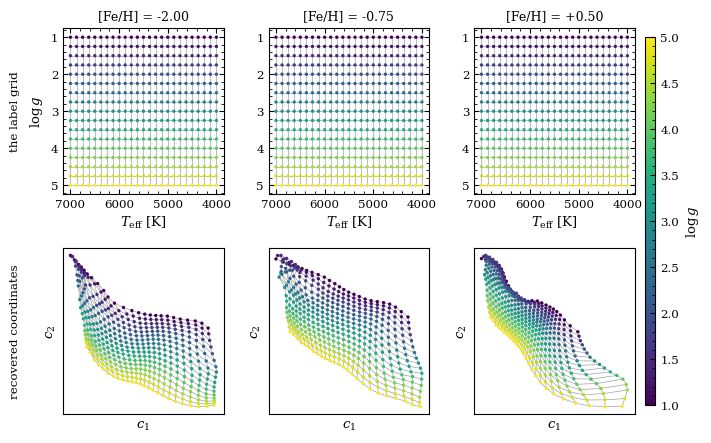

In [4]:
fig = tf.lattice(Fg.C, labels[grid], feh_values=[-2.0, -0.75, 0.5]); plt.show()

## 3. The method, step by step

The paper's Figure 1 sketches the seven steps on a toy manifold. Here they are drawn on real spectra: the (Teff, log g) sheet of the grid at solar metallicity, 425 spectra, every panel computed with the package's own functions.

1. **distance** — two spectra (the coolest giant and the hottest dwarf of the sheet) over one wavelength chunk, and below them their cumulative absorption curves; the shaded area between the curves is their distance in that chunk.
2. **all pairs** — the table of distances between every pair of stars, ordered along the sheet.
3. **graph** — every star joined to its nearest neighbours under the distance, drawn on a projection of the spectra themselves (their first three principal components), which is a crumpled sheet.
4. **geodesic** — the shortest path through the graph between the two corner stars: distance measured *along* the sheet, not across the fold.
5. **coordinates** — the geodesic distances turned into coordinates; the grid lines of constant Teff and log g drawn through the recovered positions are crumpled by the graph's jitter.
6. **refinement** — the same after the locally linear refinement, which removes that jitter.
7. **labels** — the temperature of four stars (the orange stars) spread to every other star through the same local weights.

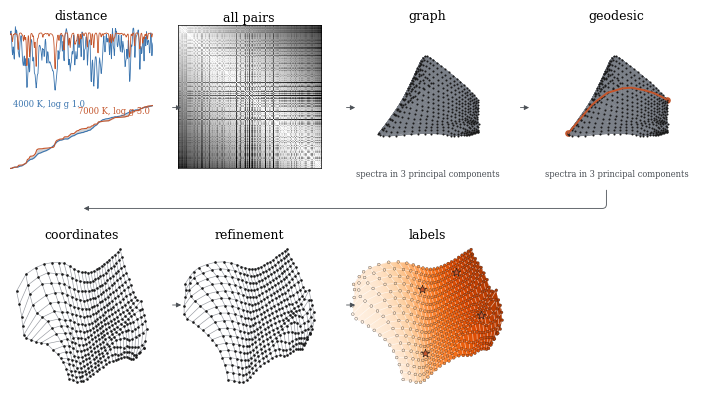

Teff from four labelled stars: 1-sigma error 265 K on the other 421


In [5]:
lab_g = labels[grid]; sheet = np.isclose(lab_g[:, 2], 0.0)
f_sheet = flux[grid][sheet]; L_sheet = lab_g[sheet][:, :2]
Fs = ar.fit(f_sheet, np.ones(f_sheet.shape, bool), np.zeros(f_sheet.shape[1], int), ar.Config.paper_synthetic(d=2), log=None)
four = tf.pick_labelled(L_sheet)                                     # four stars spread over the sheet
teff = Fs.propagate(L_sheet[:, :1], labelled_index=four)[:, 0]        # their Teff carried to the other 421
fig = tf.schematic(Fs, f_sheet, wl, L_sheet, four, teff, chunk=(1800, 2200)); plt.show()
others = np.setdiff1d(np.arange(len(teff)), four)
print(f"Teff from four labelled stars: 1-sigma error {ev.error(teff[others] - L_sheet[others, 0]):.0f} K on the other {len(others)}")

## 4. Labels for a survey-like sample from a few labelled stars

The population sample is what a survey looks like: main-sequence stars, subgiants, giants and red-clump stars, at the proportions of a magnitude-limited sample. Fit its coordinates, then suppose only 50 stars have measured labels. `Fit.propagate` takes the labels of those stars and returns a value for every star, by asking that each star's labels be the same local linear combination of its neighbours' labels as its spectrum is of their spectra.

The error statistic used throughout is `evaluate.error`: half the central 68 per cent range of the differences, the width of a Gaussian with the same core, so that the few stars a graph places wrongly do not set the number.

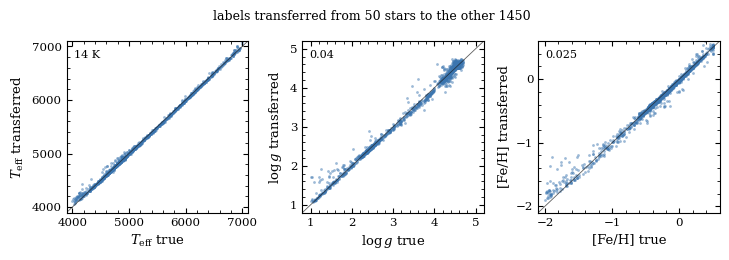

In [6]:
pop = sample == "population"; Np = pop.sum()
Fp = ar.fit(flux[pop], np.ones(flux[pop].shape, bool), np.zeros(flux.shape[1], int), ar.Config.paper_synthetic(), log=None)
rng = np.random.default_rng(1); labelled = rng.choice(Np, 50, replace=False); held = np.setdiff1d(np.arange(Np), labelled)
Y = Fp.propagate(labels[pop], labelled_index=labelled)
fig = tf.one_to_one(labels[pop][held], Y[held], title=f"labels transferred from 50 stars to the other {len(held)}"); plt.show()

## 5. The same with noise

Real spectra carry noise. Add Gaussian noise at a signal-to-noise ratio of 30 per pixel and repeat. The distance is built on cumulative absorption, which averages the noise within each chunk, so the coordinates and the transfer degrade gracefully.

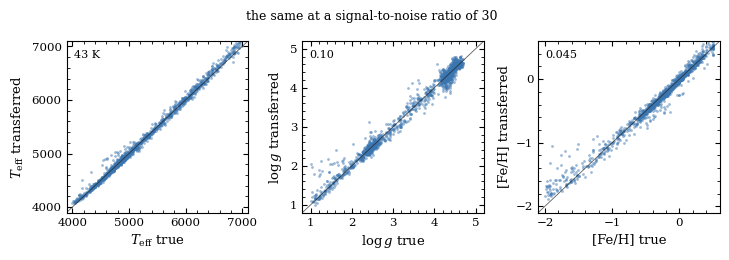

   Teff   noiseless 14.257   S/N 30 43.438
   log g  noiseless 0.044   S/N 30 0.099
   [Fe/H] noiseless 0.025   S/N 30 0.045


In [7]:
snr = 30.0
noisy = (flux[pop] + rng.normal(0, 1 / snr, flux[pop].shape)).astype(np.float32)
Fn = ar.fit(noisy, np.ones(noisy.shape, bool), np.zeros(noisy.shape[1], int), ar.Config.paper_synthetic(), log=None)
Yn = Fn.propagate(labels[pop], labelled_index=labelled)
fig = tf.one_to_one(labels[pop][held], Yn[held], title="the same at a signal-to-noise ratio of 30"); plt.show()
for name, e0, e1 in zip(["Teff", "log g", "[Fe/H]"], ev.error(Y[held] - labels[pop][held]), ev.error(Yn[held] - labels[pop][held])): print(f"   {name:6s} noiseless {e0:.3f}   S/N 30 {e1:.3f}")

## 6. Your own survey

The calls are the same for a real survey; what changes is the input and the configuration.

- **Input.** `flux [N, P]` and `good [N, P]` (False where a pixel is bad), `segments [P]` numbering the detector segments from 0 so that no chunk straddles a gap, and `err [N, P]` when the spectra still carry their instrumental response (then `Config(continuum="running")` fits a running continuum first) or when the noise varies across the spectrum in a way the errors describe (`error_weights=True`).
- **Configuration.** `Config()` is the paper's APOGEE setting (three detector segments, three chunkings of increasing fineness, four coordinates); `Config.paper_apogee_survey()` and `Config.paper_desi()` are the two survey-scale settings, with 800 landmarks and nearest-neighbour descent. Every field is documented in `armillary/pipeline.py`, and a configuration can be saved and loaded as JSON.
- **Scale.** The chain has been run on 200,000 APOGEE and 100,000 DESI spectra on one node; the neighbour search is the cost, and `Config.threads` sets the cores numba uses.
- **Saving.** `Fit.save(path)` writes the coordinates, eigenvalues, landmarks, neighbour lists and configuration to a compressed `.npz`; `Fit.propagate` can be called again later on the same `Fit` with any table of labels.

In [8]:
cfg = ar.Config.paper_apogee_survey()
print({k: v for k, v in cfg.to_dict().items() if k in ("chunkings", "k_lattice", "n_landmarks", "d", "k_refine", "search", "mu")})
Fp.save("examples/output_population_fit.npz")

{'chunkings': ((4, 4, 3), (8, 7, 5), (16, 14, 10)), 'k_lattice': 30, 'search': 'nndescent', 'n_landmarks': 800, 'd': 4, 'k_refine': 100, 'mu': 3.0}
